# Week 13 - Recurrent Neural Networks
So far in the course we have learned about the underlying concepts defining a Neural Network, and looked at the most simple type of Neural Network, a **Feed-Forward Neural Network (FNN)**. 
This part of the course will now go through some alternative, more specialised architectures which can be used for deep-learning problems.
This session and next we will cover the two most common deep learning Neural Networks: **Recurrent Neural Networks (RNNs)** and **Convolutional Neural Networks (CNNs)**. You will often hear the mnemonic that **R**NNs are useful for **R**egression, and **C**NNs are useful for **C**lassification. This is a bit of an oversimplification, as we will learn how the models can be used for a variety of situations for different tasks, but it is still helpful to remember that these are the spaces they are typically applied. RNNs are most classically used for time series and forecasting problems, which generally involves regression, whilst CNNs are most classically used for image-recognition which is primarily a classification task.

This week is quite complex and tackles some very abstract concepts. Please review these articles from [Medium](https://medium.com/@tyagi.lekhansh/cnns-vs-rnns-understanding-deep-learning-architectures-f571dd6a39c7) and [GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/introduction-to-recurrent-neural-network/) if you would like to see some alternative explanations for clarity.

## 2 - How do Recurrent Neural Networks Work?
Recurrent neural networks (RNNs) are characterised by their "memory", utilising previous information at later steps. Whilst Feed-forward Neural Networks assume inputs are independent, the output of RNNs are dependent on prior sequential information. Bi-directional RNNs may
also utilise future information to inform the output. For this reason, they are particularly appropriate for
sequential time-series output. 

### 1.1 - Architecture
Recall a traditional Feed-foward Neural Network (FNN) structure - for now with a single hidden layer. Information flows in one direction from input to output:
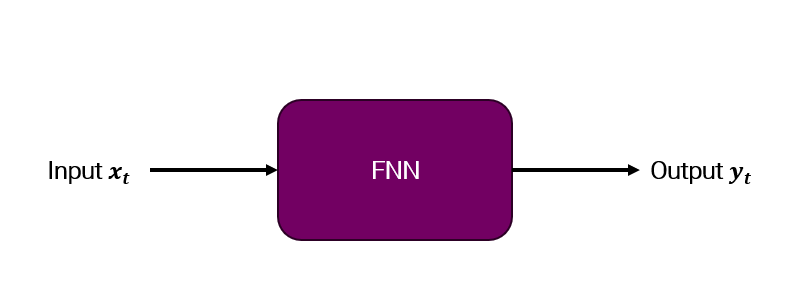

There are no cycles or memory, each prediction depends only on the current input.
Within an FNN, input data is weighted with an associated weight matrix, $W$, added to a bias, $b$ and passed through an activation function, $A$.
$$h=A\left(W\cdot x_t+b\right).$$
The model has fixed input/output structure and treats every input as independent. The hidden state, $h$, is "forgotten" after each iteration. This means it cannot capture intertemporal or sequential patterns and dependencies.

A Recursive Neural Network (RNN), is specialised for sequential and/or time-dependent data through a **remembered hidden state**. This hidden state can be thought of as the "memory" of the model, it learns from previous time steps and retains, or "remembers", the information to inform future steps. 
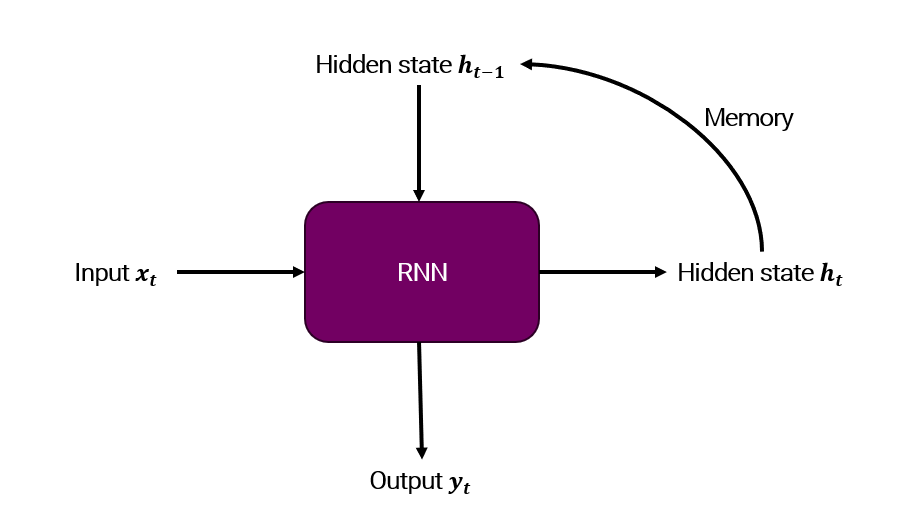

At time $t$, $h_t$ is calculated by combining the weighted input with the weighted hidden state from the previous step, again adding bias and passing through an activation function:
$$h_t = A_h\left(W_x \cdot x_t + W_h h_{t-1}+b\right),$$
The output at time $t$ is then calculated as the weighted hidden state passed through another activation function
$$y_t = A_{y}\left(W_y\cdot h_t\right).$$

The connection between the previous hidden state to the current hidden state is known as the **recurrent connection**. This function allows prior information to be retained and used to influence current and future predictions. This is the key part of the architecture, making the network "recurrent", and enabling the model to capture temporal and sequential patterns.
For a multi-layered RNN, rather than a single recurrent connection and hidden state, we have one for each layer.
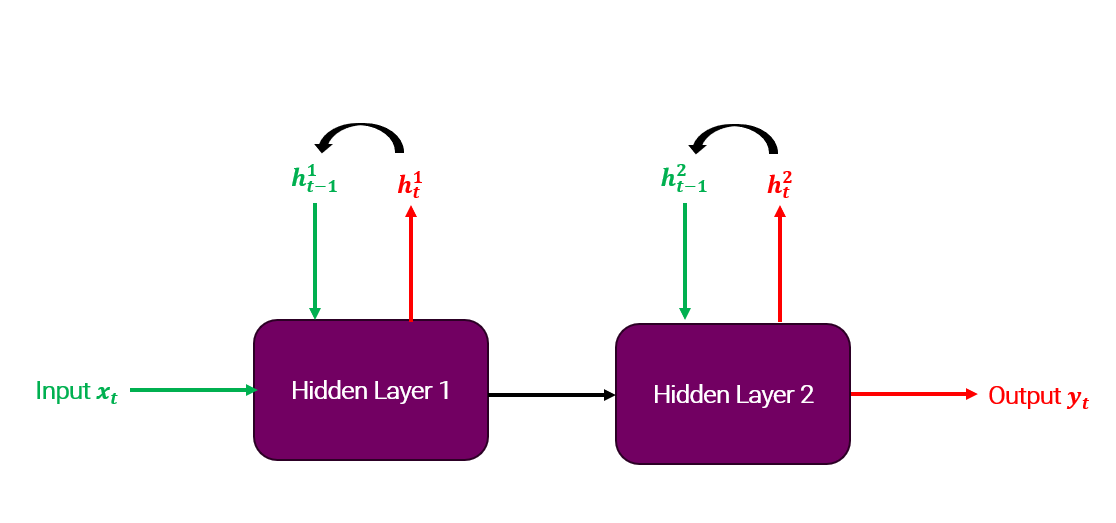



It is common to see this architecture represented as a simple loop, as above, as well as **unfolded** as below.

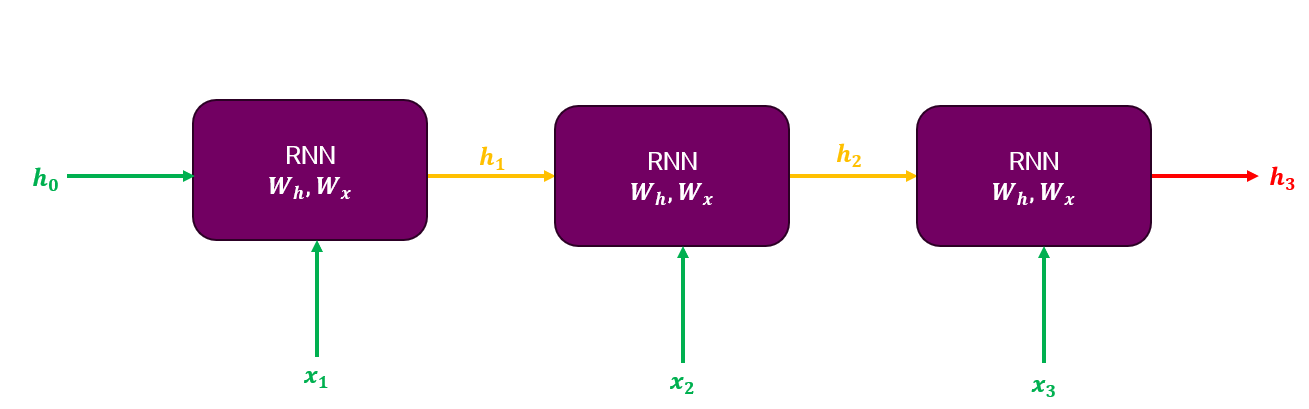

The unfolded version shows the same RNN as though it were several interconnected layers, similar to an FNN. We see that the model remains the same, with the same weights defining how the previous hidden state and the input information are used, with outputs from each time step passed forwards.


### 1.2 - Training
Similarly to FNNs, back-propagation is used to update the network's parameters, however we now have the added complexity of a recurrent architecture. The adapted method to handle this is known as **Backpropagation through time (BPTT)**.
Backpropagation through time aims to update three weight matrices: $W_y$, $W_h$ and $W_x$, to minimise loss:
$$L_n = \left(T_n-Y_n\right)^2,$$
where $n$ is the final time in the sequence, and $T$ is the true value. Note there are other loss and error functions, please refer back to the previous tutorial to review if wanted, but for now we will stick with square error.

To calculate how to optimally adjust $W_y$, we consider how $W_y$ affects $Y_n$, and how $Y_n$ affects $L_n$. To combine these two effects we use the chain rule
$$\frac{\delta L_n}{\delta W_y}=\frac{\delta L_n}{\delta Y_n}\cdot \frac{\delta Y_n}{\delta W_y}.$$
This works almost identically to FNN back-propagation.

Adjusting the hidden state weight matrix, $W_h$, is a little more compex as it affected not just the current hidden state, but all previous states as well. As such, we must sum all of these effects together, again using chain rule,
$$\frac{\delta E_n}{\delta W_h}=\sum^n_{t=1}\left(\frac{\delta E_n}{\delta W_h}\right)_t=\sum^n_{t=1}\frac{\delta E_n}{\delta Y_n} \cdot \frac{\delta Y_n}{\delta H_t}\cdot \frac{\delta H_t}{\delta W_h}.$$

Finally, we adjust the input weight matrix, $W_x$, again considering all timesteps and summing the effects as
$$\frac{\delta L_n}{\delta W_x}=\sum^n_{t=1}\left(\frac{\delta L_n}{\delta W_x}\right)_t=\sum^n_{t=1}\frac{\delta L_n}{\delta Y_n}\cdot \frac{\delta Y_n}{\delta H_t}\cdot \frac{\delta H_t}{\delta W_x}.$$

BPTT allows temporal and sequential dependencies to be captured and learned by the model. This can be incredibly useful for forecasting and other tasks involving sequential data such as speech and time-series information. It is also highly flexible, able to handle inputs of varying lengths and adapting its gradient calculations to align. However, it has two key potential issues: **Vanishing** and **Exploding Gradients**. This is the idea that when we are backpropagating over many time steps, as well as over hidden layers, gradients can become uncontrollably small (vanishing) or large (exploding). Vanishing gradients can lead to the network "forgetting" temporal dependencies, whilst exploding gradients can cause instability. 
These can be tackled using gradient clipping, which prevents gradients becoming too large. Layer normalisation can also help prevent instability issues. Additionally, using specialised architectures of RNNs can prevent these issues from occurring.

### 1.3 Specialised Types of RNNs
There are several types of specialised models commonly used to handle the issues of vanishing and exploding gradients.

Long short-term memory (LSTM) is a variation of RNN, aiming to solve the vanishing gradient problem, and
incorporate long-term intertemporal dependencies. LSTMs have "cells" within the hidden layers with three
gates controlling the flow of information, namely: input, output and forget. LSTM models are particularly good when working with very long sequences of data, or data where there are long-term and seasonal patterns.

Gated recurrent units (GRUs) also aim to incorporate long-term dependencies and solve the vanishing gradient problem. This method utilises hidden states with two gates: reset and update determining which data are retained. This model is simpler than an LSTM using fewer parameters and training faster, however this can sometimes reduce performance on very complex problems.

Residual RNNs (skip connection RNNs) add shortcut connections to help gradients propagate through deep stacks to help reduce the vanishing gradient problem.

Unitary/Orthogonal RNNs combat both vanishing and exploding gradients by constraining the weights to be orthogonal and unitary matrices.

Echo State Networks (ESNs), which will be covered more specifically in the third part of the Deep Learning section, use a fixed recurrent reservoir and train only the output weights. This removes the need for BPTT as it is done in a traditional RNN, removing the risk of exploding or vanishing gradients specific to this problem, although there is always some risk present in any form of backpropagation.


## 2 - Using a Recurrent Neural Network in Python

Let's look at a real wind energy example - we will model how to build an RNN to predict daily wind speed from the previous month of data. For this problem we will use the [Kaggle Wind Speed Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/wind-speed-prediction-dataset?resource=download), which has daily windspeed from 1961 to 1978.

First we will need to install tensorflow, if you do not already have it on your device. This is a large package so it may take longer than usual to install.

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

First we will read in the data using pandas, and extract the values corresponding to wind.

In [20]:
wind_data = pd.read_csv('wind_dataset.csv')
wind_values = wind_data.WIND.values.reshape(-1,1)

Next, we normalise the data using min-max scaling.

In [23]:
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(wind_values)

In order to get previous sequences of data, in this case 30 days, we create a function to lookback and extract.

In [24]:
def create_sequences(data, lookback=30):
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

We then utilise the function to create a dataset of sequential data (last month of wind speed history), and labels (daily wind speed).

In [25]:
LOOKBACK = 30

X, y = create_sequences(values_scaled, lookback=LOOKBACK)

print("X shape:", X.shape)  # samples, timesteps, features
print("y shape:", y.shape)

X shape: (6544, 30, 1)
y shape: (6544, 1)


This data is then split into training and test sets.

In [26]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


The model is now ready to be build. To review the activation functions used, please look at the previous tutorial. TensorFlow comes equipped with a nice `.summary()` method which can give an overview of the model created.

In [27]:
model = Sequential([
    SimpleRNN(
        units=64,
        activation="tanh",
        input_shape=(LOOKBACK, 1)
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()


C:\Users\raby\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)             │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

The model is now fitted to the training data. Epochs and Batch sizes can be adjusted to change the complexity of the training phase.

In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=False
)


Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0258 - mae: 0.1255 - val_loss: 0.0157 - val_mae: 0.1003
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0208 - mae: 0.1139 - val_loss: 0.0155 - val_mae: 0.1004
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0199 - mae: 0.1114 - val_loss: 0.0146 - val_mae: 0.0961
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0194 - mae: 0.1104 - val_loss: 0.0146 - val_mae: 0.0961
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0192 - mae: 0.1099 - val_loss: 0.0145 - val_mae: 0.0960
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0192 - mae: 0.1099 - val_loss: 0.0145 - val_mae: 0.0964
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0191 - mae: 0.1096 - val_loss: 0.0146 - val_mae: 0.0969
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0190 - mae: 0.1092 - val_loss: 0.0145 - val_mae: 0.0959
Epoch 9/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

Once the model is trained, we can use it to predict the values for the test set, and view the results.

In [36]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
mape = np.mean(
    np.abs(
        (y_test_actual.flatten() - y_pred.flatten())
        / y_test_actual.flatten()
    )
) * 100

print(f"MAPE: {mape:.2f}%")

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE:  3.054
RMSE: 3.915
MAPE: 46.17%


Additionally, we can plot the results to see how they compare.

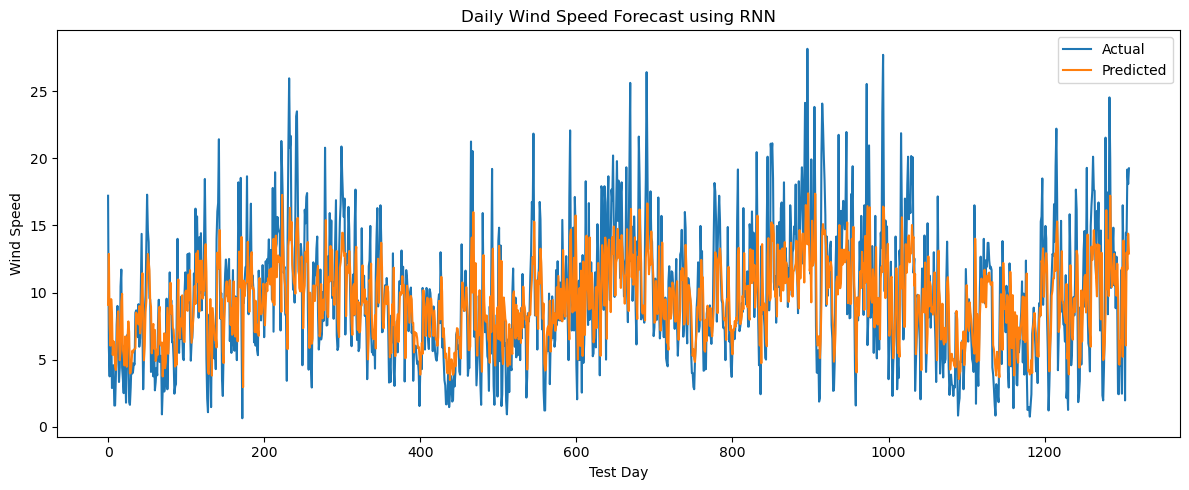

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Daily Wind Speed Forecast using RNN")
plt.xlabel("Test Day")
plt.ylabel("Wind Speed")
plt.legend()
plt.tight_layout()
plt.show()

As we can see, this model did not perform sufficiently, We miss a lot of extreme wind speeds, and the mean average percentage error is unacceptably high. How can we improve this model? First let's try changing the number of epochs, longer training often means capturing of more complex patterns.

C:\Users\raby\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)             │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0285 - mae: 0.1326 - val_loss: 0.0170 - val_mae: 0.1069
Epoch 2/1000
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0216 - mae: 0.1162 - val_loss: 0.0148 - val_mae: 0.0972
Epoch 3/1000
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0200 - mae: 0.1127 - val_loss: 0.0148 - val_mae: 0.0974
Epoch 4/1000
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0196 - mae: 0.1113 - val_loss: 0.0145 - val_mae: 0.0963
Epoch 5/1000
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0192 - mae: 0.1099 - val_loss: 0.0146 - val_mae: 0.0961
Epoch 6/1000
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0192 - mae: 0.1098 - val_loss: 0.0144 - val_mae: 0.0956
Epoch 7/1000
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0191 - mae: 0.1095 - val_loss: 0.0146 - val_mae: 0.0969
Epoch 8/1000
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0189 - mae: 0.1087 - val_loss: 0.0145 - val_mae: 0.0956
Epoch 9/1000
131/131 ━━━━━━━━━━━━━━━━━━━

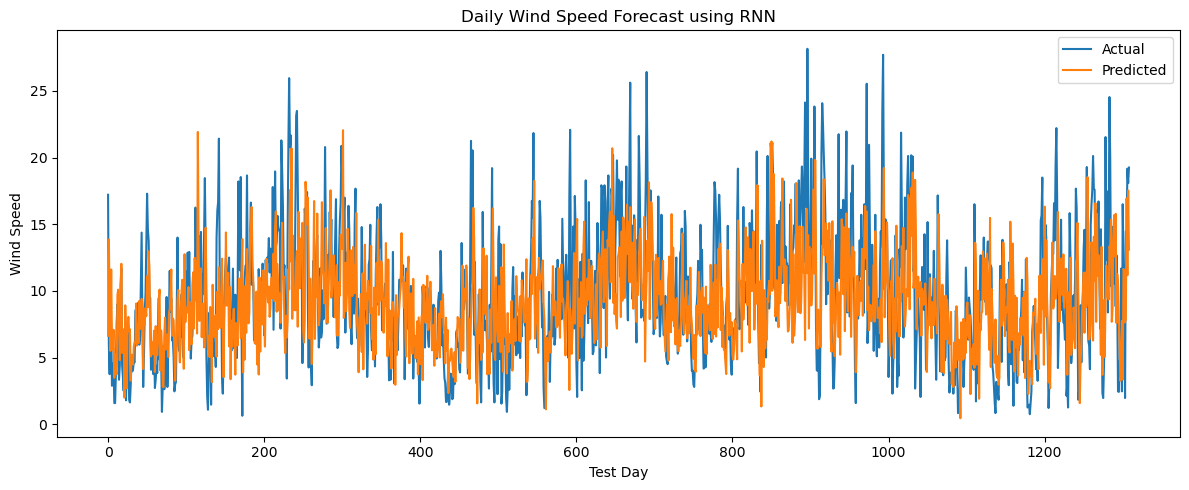

In [37]:
n_epochs = 1000

# Build RNN model
model = Sequential([
    SimpleRNN(
        units=64,
        activation="tanh",
        input_shape=(LOOKBACK, 1)
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=n_epochs,
    batch_size=32,
    validation_split=0.2,
    shuffle=False
)


# Predict
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)


#Evaluate
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
mape = np.mean(
    np.abs(
        (y_test_actual.flatten() - y_pred.flatten())
        / y_test_actual.flatten()
    )
) * 100

print(f"MAPE: {mape:.2f}%")

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Daily Wind Speed Forecast using RNN")
plt.xlabel("Test Day")
plt.ylabel("Wind Speed")
plt.legend()
plt.tight_layout()
plt.show()

We can alternatively use a more specialised model such as LSTM.

In [38]:
# Import specialised LSTM features
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

model = Sequential([
    LSTM(
        units=64,
        activation="tanh",
        input_shape=(LOOKBACK, 1)
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

# Fit LSTM model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=False
)

# Predict and test
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

mape = np.mean(
    np.abs(
        (y_test_actual.flatten() - y_pred.flatten())
        / y_test_actual.flatten()
    )
) * 100

print(f"MAPE: {mape:.2f}%")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Daily Wind Speed Forecast using RNN")
plt.xlabel("Test Day")
plt.ylabel("Wind Speed")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\raby\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0306 - mae: 0.1370 - val_loss: 0.0174 - val_mae: 0.1066
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0220 - mae: 0.1186 - val_loss: 0.0164 - val_mae: 0.1038
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0208 - mae: 0.1149 - val_loss: 0.0155 - val_mae: 0.1007
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0199 - mae: 0.1126 - val_loss: 0.0150 - val_mae: 0.0989
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0194 - mae: 0.1107 - val_loss: 0.0148 - val_mae: 0.0986
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0192 - mae: 0.1101 - val_loss: 0.0147 - val_mae: 0.0978
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0191 - mae: 0.1100 - val_loss: 0.0147 - val_mae: 0.0977
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0190 - mae: 0.1098 - val_loss: 0.0145 - val_mae: 0.0968
Epoch 9/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - lo

## 3 - Exercises
### Exercise 1
Alter the hyperparameters of the RNN model, can you improve the performance of the model?

Try changing: lookback length e.g. to 60, 90, 120

Try changing: batch size and number of epochs? Can you use a for loop for this to find a combination that works well?



### Exercise 2
The wind_data set has several other columns. Try building and testing either a simple RNN, or an LSTM to predict T.MIN or T.MAX (minimum and maximum temperature), or RAIN.